In [1]:
from functools import partial
from pathlib import Path

import numpy as np
import seaborn as sns
import torch
import torch.optim as optim
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from tqdm import tqdm

from src.utils.baseline import baseline_classification
from src.utils.data import LocalUserScaler, decode_labels, get_windows
from src.utils.feature_engineering import compute_daily_aggregates
from src.utils.metrics import calculate_classification_metrics
from src.utils.rnn_modeling import EarlyStopping, RnnClassifier, get_dataloader

In [2]:
df = get_windows(window_size=7)

In [3]:
agg_rules = {
    "mood": ["count", "mean", "std"],
    "circumplex.arousal": ["count", "mean", "std"],
    "circumplex.valence": ["count", "mean", "std"],
    "activity": ["count", "mean", "std"],
    "call": ["count"],
    "sms": ["count"],
    "screen": ["count", "sum", "mean", "std"],
    "appCat.builtin": ["count", "sum", "mean", "std"],
    "appCat.communication": ["count", "sum", "mean", "std"],
    "appCat.entertainment": ["count", "sum", "mean", "std"],
    "appCat.finance": ["count", "sum", "mean", "std"],
    "appCat.game": ["count", "sum", "mean", "std"],
    "appCat.office": ["count", "sum", "mean", "std"],
    "appCat.other": ["count", "sum", "mean", "std"],
    "appCat.social": ["count", "sum", "mean", "std"],
    "appCat.travel": ["count", "sum", "mean", "std"],
    "appCat.unknown": ["count", "sum", "mean", "std"],
    "appCat.utilities": ["count", "sum", "mean", "std"],
    "appCat.weather": ["count", "sum", "mean", "std"],
}

In [4]:
feature_df = compute_daily_aggregates(df, agg_rules)

In [5]:
# Computing the labels
# we use the trecile splits based on train data to identify discretize our labels

label_estimation_subset = feature_df.query("split == 'train'").drop_duplicates(
    subset=["window_id"]
)["target_mean_mood"]

Q33 = label_estimation_subset.quantile(1 / 3)
Q67 = label_estimation_subset.quantile(2 / 3)

print(f"Thresholds (from train):  low < {Q33:.4f}  <=  mid  < {Q67:.4f}  <= high")


def mood_to_class(mood: float, q33: float, q67: float) -> int:
    return int(0 if mood < q33 else (1 if mood < q67 else 2))


mood_to_class_vectorized = np.vectorize(partial(mood_to_class, q33=Q33, q67=Q67))


feature_df["mood_label"] = mood_to_class_vectorized(
    feature_df["target_mean_mood"].values
)

Thresholds (from train):  low < 6.8000  <=  mid  < 7.4000  <= high


In [6]:
train_df = feature_df[feature_df["split"] == "train"]
val_df = feature_df[feature_df["split"] == "val"]
test_df = feature_df[feature_df["split"] == "test"]

In [7]:
features_to_scale = [f"{k}_{agg_func}" for k, v in agg_rules.items() for agg_func in v]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", LocalUserScaler(id_col="id"), ["id"] + features_to_scale),
        ("user_id", "passthrough", ["id"]),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

pipeline = Pipeline(steps=[("scaler", preprocessor)])
pipeline.set_output(transform="pandas")
pipeline.fit(train_df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('user_id', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [8]:
train_dataloader = get_dataloader(
    dataset_kwargs={"df": train_df, "label_col": "mood_label"},
    dataloader_kwargs={"batch_size": 64, "shuffle": True, "num_workers": 1},
)

val_dataloader = get_dataloader(
    dataset_kwargs={"df": val_df, "label_col": "mood_label"},
    dataloader_kwargs={"batch_size": 64, "shuffle": True, "num_workers": 1},
)

test_dataloader = get_dataloader(
    dataset_kwargs={"df": test_df, "label_col": "mood_label"},
    dataloader_kwargs={"batch_size": 64, "shuffle": False, "num_workers": 1},
)

Train:  {'Macro': {'F1': 0.4372}, 'Micro': {'F1': 0.4375}}
Val:  {'Macro': {'F1': 0.4279}, 'Micro': {'F1': 0.5}}
Test:  {'Macro': {'F1': 0.4253}, 'Micro': {'F1': 0.4593}}


Text(0.5, 1.0, 'Baseline Confusion Matrix (TEST)')

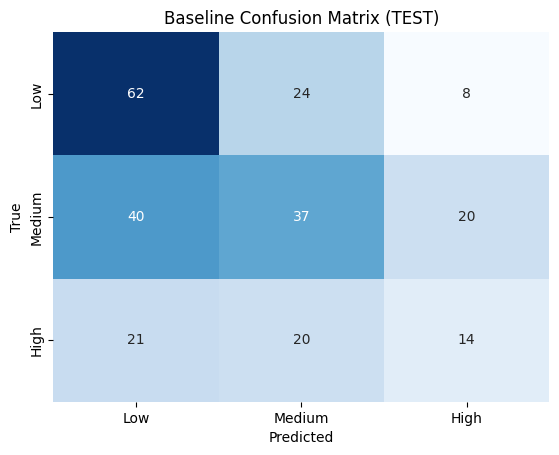

In [9]:
train_metrics = calculate_classification_metrics(
    *baseline_classification(train_df, mood_to_class_vectorized)
)
val_metrics = calculate_classification_metrics(
    *baseline_classification(val_df, mood_to_class_vectorized)
)
test_metrics = calculate_classification_metrics(
    *baseline_classification(test_df, mood_to_class_vectorized)
)

print("Train: ", train_metrics)
print("Val: ", val_metrics)
print("Test: ", test_metrics)

# val_metrics = calculate_regression_metrics(*baseline_regression(val_df), preprocessor)
# test_metrics = calculate_regression_metrics(*baseline_regression(test_df), preprocessor)

# test_metrics
y_true, y_pred = baseline_classification(test_df, mood_to_class_vectorized)

cm = confusion_matrix(y_true, y_pred)
plot = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
    cbar=False,
)
plot.set_xlabel("Predicted")
plot.set_ylabel("True")
plot.set_title("Baseline Confusion Matrix (TEST)")

In [10]:
model = RnnClassifier(
    n_classes=3,
    n_features=len(
        train_df.columns.drop(
            ["id", "window_id", "date", "target_mean_mood", "mood_label", "split"]
        )
    ),
    hidden_dim=64,
)

In [11]:
save_path = Path("./best_rnn_model.pt")

optimizer = optim.Adam(model.parameters(), lr=0.001)
stopper = EarlyStopping(patience=3, path=save_path)


# Calculate weights based on your training distribution
# weights = total_samples / (n_classes * class_samples)
counts = torch.tensor(
    train_df.drop_duplicates(subset=["window_id"])["mood_label"]
    .value_counts()
    .sort_index()
    .to_list(),
    dtype=torch.float,
)
weights = counts.max() / counts
weights = weights / weights.sum()  # Normalize

criterion = torch.nn.CrossEntropyLoss(weight=weights)

In [ ]:
epochs = 100
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0

    pbar = tqdm(train_dataloader, desc=f"Training Epoch {epoch + 1}/{epochs}")
    for x, y, user_idx in pbar:
        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y.view(-1, 1))

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_dataloader)

    # --- VALIDATION ---
    model.eval()
    val_mse = 0
    val_unscaled_mse = 0

    pbar = tqdm(val_dataloader, desc=f"Validation Epoch: {epoch + 1}/{epochs}")
    with torch.no_grad():
        for x, y, u in pbar:
            # outputs = model(x, u)
            outputs = model(x)
            val_mse += criterion(outputs, y.view(-1, 1)).item()

            y_true = y.view(-1).numpy()
            y_pred = outputs.view(-1).numpy()

            metrics = calculate_classification_metrics(y_true, y_pred)

            val_unscaled_mse += metrics["Macro"]["F1"]

    avg_val_loss = val_mse / len(val_dataloader)
    avg_val_rmse = (val_unscaled_mse / len(val_dataloader)) ** 0.5

    print(f">> Epoch {epoch + 1} Results:")
    print(f"   Train MSE: {avg_train_loss:.2f}")
    print(
        f"   Val   MSE: {avg_val_loss:.2f} | RMSE: {avg_val_rmse:.2f} Avg Mood Points"
    )
    print("\n")

    # --- EARLY STOPPING CHECK ---
    if stopper(avg_val_loss, model):
        print(
            f"\nEarly stopping triggered. No improvement for {stopper.patience} epochs."
        )
        model = torch.load(save_path, weights_only=False)
        break

Validation Epoch: 1/100: 100%|██████████| 3/3 [00:00<00:00, 23.25it/s]


>> Epoch 1 Results:
   Train MSE: 1.34
   Val   MSE: 1.07 | RMSE: 0.72 Avg Mood Points




Validation Epoch: 2/100: 100%|██████████| 3/3 [00:00<00:00, 39.18it/s]


>> Epoch 2 Results:
   Train MSE: 1.14
   Val   MSE: 1.03 | RMSE: 0.72 Avg Mood Points




Validation Epoch: 3/100: 100%|██████████| 3/3 [00:00<00:00, 44.11it/s]


>> Epoch 3 Results:
   Train MSE: 1.06
   Val   MSE: 0.94 | RMSE: 0.69 Avg Mood Points




Validation Epoch: 4/100: 100%|██████████| 3/3 [00:00<00:00, 42.69it/s]


>> Epoch 4 Results:
   Train MSE: 1.06
   Val   MSE: 1.14 | RMSE: 0.79 Avg Mood Points




Validation Epoch: 5/100: 100%|██████████| 3/3 [00:00<00:00, 42.85it/s]


>> Epoch 5 Results:
   Train MSE: 0.98
   Val   MSE: 1.25 | RMSE: 0.79 Avg Mood Points




Validation Epoch: 6/100: 100%|██████████| 3/3 [00:00<00:00, 42.77it/s]

>> Epoch 6 Results:
   Train MSE: 0.94
   Val   MSE: 1.44 | RMSE: 0.85 Avg Mood Points



Early stopping triggered. No improvement for 3 epochs.


In [ ]:
# Testing

In [23]:
model.eval()
with torch.no_grad():
    y_labels = []
    y_preds = []
    user_ids = []
    for x, y, u in tqdm(test_dataloader):
        y_preds.append(model(x).squeeze())
        y_labels.append(y.squeeze())
        user_ids.extend(u)

    y_labels = torch.hstack(y_labels).numpy()
    y_preds = torch.hstack(y_preds).numpy()

    print(calculate_regression_metrics(y_labels, y_preds, user_ids, preprocessor))

    y_true_decoded = decode_labels(preprocessor, user_ids, y_labels)
    y_pred_decoded = decode_labels(preprocessor, user_ids, y_preds)

100%|██████████| 4/4 [00:00<00:00, 37.68it/s]

{'Micro': {'MSE': 0.4165, 'RMSE': np.float64(0.6454), 'MAE': 0.4805}, 'Macro': {'MSE': np.float64(0.3982), 'RMSE': np.float64(0.622), 'MAE': np.float64(0.4758)}}


In [24]:
from plotly import graph_objects as go

In [25]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=y_true_decoded,
        y=y_pred_decoded,
        mode="markers",
        name="Predictions vs True",
    )
)

In [133]:
print(
    f"Test RMSE: {np.mean((np.array(y_labels) - np.array(y_preds)) ** 2) ** 0.5:.2f} Avg Mood Points"
)

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=y_labels, y=y_preds, mode="markers", name="Predictions vs True")
)

Test RMSE: 1.18 Avg Mood Points
